In [2]:
pip install pillow opencv-python tensorflow matplotlib


Note: you may need to restart the kernel to use updated packages.


In [1]:
import os
from PIL import Image


In [6]:
dataset_path = "C:/Users/akrit/OneDrive/Desktop/FlowerRecognition/dataset"

In [7]:
import os
os.listdir(dataset_path)


['Jasmine', 'red zonal geraniums', 'Rose']

In [8]:
for folder in os.listdir(dataset_path):
    
    folder_path = os.path.join(dataset_path, folder)
    
    if os.path.isdir(folder_path):
        
        for file in os.listdir(folder_path):
            
            file_path = os.path.join(folder_path, file)

            try:
                img = Image.open(file_path)
                img = img.convert("RGB")
                img = img.resize((224,224))
                img.save(file_path)

            except:
                print("Skipped:", file_path)

print("All images resized successfully")

All images resized successfully


In [9]:
import tensorflow as tf

dataset_path = "C:/Users/akrit/OneDrive/Desktop/FlowerRecognition/dataset"

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224,224),
    batch_size=32
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224,224),
    batch_size=32
)

Found 247 files belonging to 3 classes.
Using 198 files for training.
Found 247 files belonging to 3 classes.
Using 49 files for validation.


In [10]:
class_names = train_ds.class_names
print(class_names)

['Jasmine', 'Rose', 'red zonal geraniums']


In [11]:
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

model = Sequential([
    
    layers.Rescaling(1./255, input_shape=(224,224,3)),

    layers.Conv2D(32,3,activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64,3,activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128,3,activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),
    layers.Dense(len(class_names),activation='softmax')
])

C:\Users\akrit\anaconda3\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [12]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [13]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 815ms/step - accuracy: 0.3182 - loss: 2.0852 - val_accuracy: 0.5306 - val_loss: 0.9118
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 556ms/step - accuracy: 0.6313 - loss: 0.8390 - val_accuracy: 0.6735 - val_loss: 0.6423
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 546ms/step - accuracy: 0.6414 - loss: 0.6546 - val_accuracy: 0.6735 - val_loss: 0.6210
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 591ms/step - accuracy: 0.7778 - loss: 0.5170 - val_accuracy: 0.7347 - val_loss: 0.5544
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 543ms/step - accuracy: 0.7778 - loss: 0.4670 - val_accuracy: 0.7551 - val_loss: 0.4456
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 554ms/step - accuracy: 0.8939 - loss: 0.2958 - val_accuracy: 0.8776 - val_loss: 0.3440
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 537ms/step - accuracy: 0.9091 - loss: 0.2223 - val_accuracy: 0.8571 - val_loss: 0.3937
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 531ms/step - accuracy: 0.9444 - loss: 0.1824 - val_accuracy: 0.6531 - val_loss:

In [14]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 568ms/step - accuracy: 0.9848 - loss: 0.0620 - val_accuracy: 0.8163 - val_loss: 0.5865
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 593ms/step - accuracy: 1.0000 - loss: 0.0327 - val_accuracy: 0.7551 - val_loss: 0.8717
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 550ms/step - accuracy: 0.9899 - loss: 0.0235 - val_accuracy: 0.7347 - val_loss: 0.8822
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 550ms/step - accuracy: 1.0000 - loss: 0.0094 - val_accuracy: 0.7551 - val_loss: 0.8134
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 538ms/step - accuracy: 1.0000 - loss: 0.0063 - val_accuracy: 0.7959 - val_loss: 0.5066
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 543ms/step - accuracy: 1.0000 - loss: 0.0061 - val_accuracy: 0.7551 - val_loss: 0.8001
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 528ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 0.7347 - val_loss: 1.3870
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 538ms/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 0.7347 - val_loss:

In [17]:
test_path = "C:/Users/akrit/OneDrive/Desktop/FlowerRecognition/testing/zonal_geranium_test"

In [19]:
import os
os.listdir("C:/Users/akrit/OneDrive/Desktop/FlowerRecognition")

['dataset', 'testing']

In [20]:
os.listdir("C:/Users/akrit/OneDrive/Desktop/FlowerRecognition/testing")

['zonal geranium test']

In [21]:
test_path = "C:/Users/akrit/OneDrive/Desktop/FlowerRecognition/testing/zonal geranium test"

In [22]:
for file in os.listdir(test_path):

    img_path = os.path.join(test_path, file)

    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)

    predicted_class = class_names[np.argmax(prediction)]

    print(file, "→ Predicted:", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 547ms/step
20260314_185653.jpg.jpeg → Predicted: Rose
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
20260314_185656.jpg.jpeg → Predicted: red zonal geraniums
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
20260314_185659.jpg.jpeg → Predicted: red zonal geraniums


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

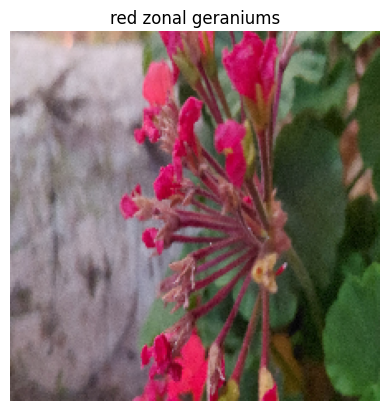

In [23]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.title(predicted_class)
plt.axis("off")